In [ ]:
import os
os.chdir("..")


/tmp/ipykernel_113188/2102031805.py:70: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_kso = pd.read_csv(file_path, delim_whitespace=True, header=None,


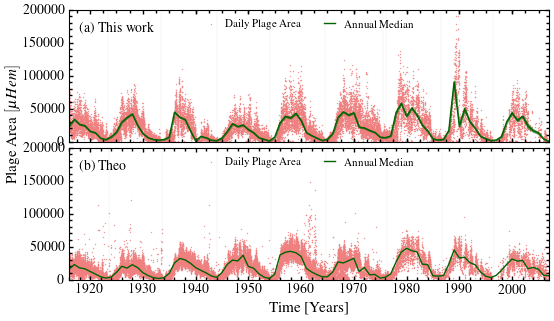

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # <-- Missing import added
from datetime import datetime, timedelta
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from matplotlib.dates import date2num
import matplotlib as mpl
from scipy.stats import pearsonr, spearmanr
import matplotlib.dates as mdates
mpl.style.use('bkj_style.mplstyle')

plt.rcParams['font.size'] = 11

fig=plt.figure(figsize = (8,6))
#ax1 = fig.add_axes([0.01,0.01,0.6, 0.22]) # priyal (2017)
ax2 = fig.add_axes([0.01, 0.24, 0.6, 0.22])  # chatterjee (2016)
ax3 = fig.add_axes([0.01, 0.47, 0.6, 0.22])  # jha (2024)


# --- Load Data ---
df_sunchart = pd.read_csv('data/filtered_sunchart_non_zero.txt', sep='\s+', header=None)
dates_sunchart = pd.to_datetime(df_sunchart[0])
plage_areas_sunchart = df_sunchart.drop(columns=0).values
total_plage_area_sunchart = np.sum(plage_areas_sunchart, axis=1)

# --- Compute Annual Median ---
data_sunchart = pd.DataFrame({'Date': dates_sunchart, 'Total_Plage': total_plage_area_sunchart})
data_sunchart['Year'] = data_sunchart['Date'].dt.year



# Calculate median, MAD, and SEMedian for each year
def mad(x):
    return np.median(np.abs(x - np.median(x)))

def semedian(x):
    n = len(x)
    return 1.253 * mad(x) / np.sqrt(n)

annual_stats = data_sunchart.groupby('Year')['Total_Plage'].agg(['median', mad, semedian]).reset_index()
annual_stats['Date'] = pd.to_datetime(annual_stats['Year'], format='%Y')

# 1. Original daily plage area (thin red line)
ax3.scatter(data_sunchart['Date'], data_sunchart['Total_Plage'], 
         color='lightcoral', s=0.3,alpha=0.7, linewidth=0.5, label='Daily Plage Area')

# 2. Annual median (thick solid blue line)
ax3.plot(annual_stats['Date'], annual_stats['median'], 
         color='darkgreen', linewidth=1.0, label='Annual Median')
ax3.fill_between(annual_stats['Date'], 
                annual_stats['median'] - annual_stats['semedian'],
                annual_stats['median'] + annual_stats['semedian'],
                color='darkgreen', alpha=0.5)
ax3.set_ylim(0, 200000)
ax3.set_xlim(datetime(1916, 1, 1), datetime(2007, 1, 1))
ax3.set_yticks([0, 50000, 100000, 150000, 200000])
ax3.set_xticks([datetime(1920,1,1), datetime(1930,1,1),datetime(1940,1,1), datetime(1950,1,1),datetime(1960,1,1), datetime(1970,1,1),datetime(1980,1,1), datetime(1990,1,1),datetime(2000,1,1)])
ax3.tick_params(axis='both', labelsize=10,labelbottom=False)
# plt.ylabel('Total Plage Area')
#ax1.grid(True, linestyle='--', alpha=0.5)
ax3.legend(ncols=2,loc='upper center',handlelength=1.0,fontsize=8)
ax3.text(0.02, 0.83, '(a) This work', transform=ax3.transAxes, fontsize=10)
ax3.grid()



# Load data with proper column names
file_path = "kso_plage1.txt"
df_kso = pd.read_csv(file_path, delim_whitespace=True, header=None,
                    names=['year', 'month', 'day', 'hour', 'minute', 'date_fract',
                          'julian_date', 'disc_area_px', 'plage_proj', 'plage_corr'])

# Convert numeric columns - handle potential non-numeric values
numeric_cols = ['year', 'month', 'day', 'hour', 'minute', 'plage_corr']
for col in numeric_cols:
    df_kso[col] = pd.to_numeric(df_kso[col], errors='coerce')
    
# Drop rows with invalid numeric values
df_kso = df_kso.dropna(subset=numeric_cols)

# Create datetime column - SAFER APPROACH
df_kso['datetime'] = pd.to_datetime({
    'year': df_kso['year'],
    'month': df_kso['month'],
    'day': df_kso['day'],
    'hour': df_kso['hour'],
    'minute': df_kso['minute']
})

# Function to convert to fractional year
def to_fractional_year(row):
    dt = row['datetime']
    start_of_year = datetime(int(row['year']), 1, 1)
    end_of_year = datetime(int(row['year']) + 1, 1, 1)
    seconds_in_year = (end_of_year - start_of_year).total_seconds()
    seconds_since_start = (dt - start_of_year).total_seconds()
    return row['year'] + seconds_since_start / seconds_in_year

df_kso["fractional_year"] = df_kso.apply(to_fractional_year, axis=1)

# Calculate annual median
annual_median = df_kso.groupby('year')['plage_corr'].median().reset_index()
annual_median['fractional_year'] = annual_median['year']


ax2.scatter(df_kso["fractional_year"], df_kso["plage_corr"], 
           color='lightcoral', s=0.3,alpha=0.7, linewidth=0.5, label='Daily Plage Area')
ax2.plot(annual_median['fractional_year'], annual_median['plage_corr'],
        color='darkgreen', linewidth=1.0, label='Annual Median')

ax2.set_ylim(0, 200000)
ax2.set_xlim(1916,2007)
ax2.set_yticks([0, 50000, 100000, 150000, 200000])
ax2.set_xticks([1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000])
ax2.tick_params(axis='both', labelsize=10)#,labelbottom=False)
ax2.legend(ncols=2,loc='upper center',handlelength=1.0,fontsize=8)
ax2.text(0.02, 0.83, '(b) Theo', transform=ax2.transAxes, fontsize=10)
ax2.grid()

ax2.set_xlabel('Time [Years]')



# ax1.axvline(1923.6, color='black',linestyle='-',linewidth=0.3,alpha=0.05)
# ax1.axvline(1933.7, color='black',linestyle='-',linewidth=0.3,alpha=0.05)
# ax1.axvline(1944.1, color='black',linestyle='-',linewidth=0.3,alpha=0.05)
# ax1.axvline(1954.3, color='black',linestyle='-',linewidth=0.3,alpha=0.05)
# ax1.axvline(1964.8, color='black',linestyle='-',linewidth=0.3,alpha=0.05)
# ax1.axvline(1976.2, color='black',linestyle='-',linewidth=0.3,alpha=0.05)
# ax1.axvline(1986.7, color='black',linestyle='-',linewidth=0.3,alpha=0.05)
# ax1.axvline(1996.6, color='black',linestyle='-',linewidth=0.3,alpha=0.05)
# ax1.axvline(2007.5, color='black',linestyle='-',linewidth=0.3,alpha=0.05)

# ax1.text(1917.1, -80, '15',size=10)
# ax1.text(1927.1, -80, '16',size=10)
# ax1.text(1938.1, -80, '17',size=10)
# ax1.text(1948.1, -80, '18',size=10)
# ax1.text(1958.1, -80, '19',size=10)
# ax1.text(1969.1, -80, '20',size=10)
# ax1.text(1980.1, -80, '21',size=10)
# ax1.text(1990.1, -80, '22',size=10)
# ax1.text(2001.1, -80, '23',size=10)

ax2.axvline(1923.6, color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(1933.7, color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(1944.1, color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(1954.3, color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(1964.8, color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(1976.2, color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(1986.7, color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(1996.6, color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(2007.5, color='black',linestyle='-',linewidth=0.3,alpha=0.1)

ax3.axvline(datetime(1923,6,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1933,7,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1944,1,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1954,3,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1964,8,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1976,2,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1986,7,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1996,6,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(2007.5, color='black',linestyle='-',linewidth=0.3,alpha=0.1)


fig.text(-0.07, 0.5, r'Plage Area $[\mu Hem]$', va='center', rotation='vertical')

plt.savefig('plage_area.pdf', bbox_inches='tight', dpi=300)
plt.show()

average_area_sunchart = annual_stats['median']
#print(annual_stats['Date'])
#print(annual_stats['median'])
#print(average_area_sunchart)

/tmp/ipykernel_59143/658600232.py:36: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_kso = pd.read_csv(file_path, delim_whitespace=True, header=None,


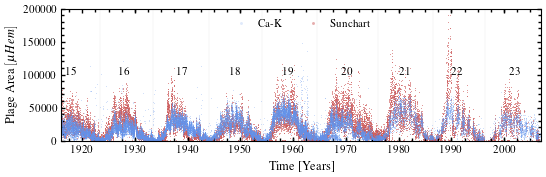

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # <-- Missing import added
from datetime import datetime, timedelta
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from matplotlib.dates import date2num
import matplotlib as mpl
from scipy.stats import pearsonr, spearmanr
import matplotlib.dates as mdates
mpl.style.use('bkj_style.mplstyle')

plt.rcParams['font.size'] = 9

fig=plt.figure(figsize = (8,6))

ax3 = fig.add_axes([0.01, 0.47, 0.6, 0.22]) 


# --- Load Data ---
df_sunchart = pd.read_csv('data/filtered_sunchart_non_zero.txt', sep='\s+', header=None)
dates_sunchart = pd.to_datetime(df_sunchart[0])
plage_areas_sunchart = df_sunchart.drop(columns=0).values
total_plage_area_sunchart = np.sum(plage_areas_sunchart, axis=1)

# --- Compute Annual Median ---
data_sunchart = pd.DataFrame({'Date': dates_sunchart, 'Total_Plage': total_plage_area_sunchart})
data_sunchart['Year'] = data_sunchart['Date'].dt.year





# Load data with proper column names
file_path = "kso_plage1.txt"
df_kso = pd.read_csv(file_path, delim_whitespace=True, header=None,
                    names=['year', 'month', 'day', 'hour', 'minute', 'date_fract',
                          'julian_date', 'disc_area_px', 'plage_proj', 'plage_corr'])

# Convert numeric columns - handle potential non-numeric values
numeric_cols = ['year', 'month', 'day', 'hour', 'minute', 'plage_corr']
for col in numeric_cols:
    df_kso[col] = pd.to_numeric(df_kso[col], errors='coerce')
    
# Drop rows with invalid numeric values
df_kso = df_kso.dropna(subset=numeric_cols)

# Create datetime column - SAFER APPROACH
df_kso['datetime'] = pd.to_datetime({
    'year': df_kso['year'],
    'month': df_kso['month'],
    'day': df_kso['day'],
    'hour': df_kso['hour'],
    'minute': df_kso['minute']
})

# Function to convert to fractional year
def to_fractional_year(row):
    dt = row['datetime']
    start_of_year = datetime(int(row['year']), 1, 1)
    end_of_year = datetime(int(row['year']) + 1, 1, 1)
    seconds_in_year = (end_of_year - start_of_year).total_seconds()
    seconds_since_start = (dt - start_of_year).total_seconds()
    return row['year'] + seconds_since_start / seconds_in_year

df_kso["fractional_year"] = df_kso.apply(to_fractional_year, axis=1)

df_kso['datetime'] = pd.to_datetime(df_kso['year'].astype(int), format='%Y') + \
                     pd.to_timedelta((df_kso['fractional_year'] - df_kso['year']) * 365, unit='D')


# Plot Ca-K data with adjusted parameters
ax3.scatter(df_kso['datetime'], df_kso['plage_corr'], 
           color='cornflowerblue', s=0.5, alpha=0.2, linewidth=0, label='Ca-K',zorder=2,rasterized=True)

ax3.scatter(data_sunchart['Date'], data_sunchart['Total_Plage'], 
           color='indianred', s=0.5, alpha=0.5, linewidth=0, label='Sunchart',rasterized=True)

ax3.set_xlim(datetime(1916, 1, 1), datetime(2007, 1, 1))
ax3.set_ylim(0, 200000)  # Slightly above max Ca-K value
ax3.set_yticks([0, 50000, 100000, 150000, 200000])
#ax3.set_xticks([datetime(1920,1,1), datetime(1930,1,1),datetime(1940,1,1), datetime(1950,1,1),datetime(1960,1,1), datetime(1970,1,1),datetime(1980,1,1), datetime(1990,1,1),datetime(2000,1,1)])
ax3.tick_params(axis='both', labelsize=8)
#ax3.legend(ncols=2,loc='upper center',handlelength=1.0,fontsize=8)
# Custom legend with larger markers
legend = ax3.legend(ncols=2, loc='upper center', handlelength=1.5, fontsize=8,
                   markerscale=3)  # markerscale makes legend markers larger
ax3.grid()

ax3.set_xlabel('Time [Years]')
ax3.set_ylabel(r'Plage Area $[\mu Hem]$')



ax3.axvline(datetime(1923,6,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1933,7,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1944,1,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1954,3,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1964,8,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1976,2,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1986,7,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1996,6,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(2007,5,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)


ax3.text(datetime(1917,1,1), 100000, '15',size=8)
ax3.text(datetime(1927,1,1), 100000, '16',size=8)
ax3.text(datetime(1938,1,1), 100000, '17',size=8)
ax3.text(datetime(1948,1,1), 100000, '18',size=8)
ax3.text(datetime(1958,1,1), 100000, '19',size=8)
ax3.text(datetime(1969,1,1), 100000, '20',size=8)
ax3.text(datetime(1980,1,1), 100000, '21',size=8)
ax3.text(datetime(1990,1,1), 100000,'22',size=8)
ax3.text(datetime(2001,1,1), 100000, '23',size=8)


plt.savefig('plage_area.pdf', bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_59143/3715022752.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_kso = pd.read_csv("kso_plage1.txt", delim_whitespace=True, header=None,


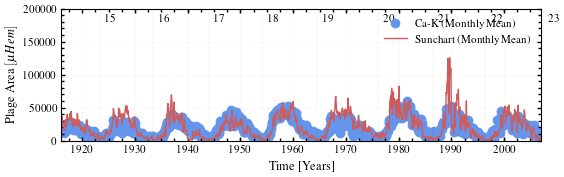

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

plt.rcParams['font.size'] = 9


fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0.01, 0.47, 0.6, 0.22]) 

# --- Load and prepare Sunchart data ---
df_sunchart = pd.read_csv('data/filtered_sunchart_non_zero.txt', sep='\s+', header=None)
dates_sunchart = pd.to_datetime(df_sunchart[0])
plage_areas_sunchart = df_sunchart.drop(columns=0).values
total_plage_area_sunchart = np.sum(plage_areas_sunchart, axis=1)

# Create DataFrame and add year-month column
data_sunchart = pd.DataFrame({'Date': dates_sunchart, 'Total_Plage': total_plage_area_sunchart})
data_sunchart['YearMonth'] = data_sunchart['Date'].dt.to_period('M')

# Calculate monthly means for Sunchart
monthly_sunchart = data_sunchart.groupby('YearMonth')['Total_Plage'].mean().reset_index()
monthly_sunchart['YearMonth'] = monthly_sunchart['YearMonth'].dt.to_timestamp()

# --- Load and prepare KSO Ca-K data ---
df_kso = pd.read_csv("data/kso_plage1.txt", delim_whitespace=True, header=None,
                    names=['year', 'month', 'day', 'hour', 'minute', 'date_fract',
                          'julian_date', 'disc_area_px', 'plage_proj', 'plage_corr'])

# Convert numeric columns and drop invalid values
numeric_cols = ['year', 'month', 'day', 'hour', 'minute', 'plage_corr']
for col in numeric_cols:
    df_kso[col] = pd.to_numeric(df_kso[col], errors='coerce')
df_kso = df_kso.dropna(subset=numeric_cols)

# Create datetime column and year-month
df_kso['datetime'] = pd.to_datetime({
    'year': df_kso['year'],
    'month': df_kso['month'],
    'day': df_kso['day'],
    'hour': df_kso['hour'],
    'minute': df_kso['minute']
})
df_kso['YearMonth'] = df_kso['datetime'].dt.to_period('M')

# Calculate monthly means for Ca-K
monthly_kso = df_kso.groupby('YearMonth')['plage_corr'].mean().reset_index()
monthly_kso['YearMonth'] = monthly_kso['YearMonth'].dt.to_timestamp()

# --- Plotting ---
# Plot monthly means as lines
ax.plot(monthly_kso['YearMonth'], monthly_kso['plage_corr'], 
        color='cornflowerblue', linewidth=1, label='Ca-K (Monthly Mean)')
ax.plot(monthly_sunchart['YearMonth'], monthly_sunchart['Total_Plage'], 
        color='indianred', linewidth=1, label='Sunchart (Monthly Mean)')

# Formatting
ax.set_xlim(datetime(1916, 1, 1), datetime(2007, 1, 1))
ax.set_ylim(0, 200000)
ax.set_yticks([0, 50000, 100000, 150000, 200000])
ax.tick_params(axis='both', labelsize=8)
ax.grid(True)

ax.set_xlabel('Time [Years]')
ax.set_ylabel(r'Plage Area $[\mu Hem]$')
ax.legend(loc='upper right', fontsize=8)

# Add solar cycle numbers and vertical lines
cycle_dates = [
    (datetime(1923,6,1), '15'),
    (datetime(1933,7,1), '16'),
    (datetime(1944,1,1), '17'),
    (datetime(1954,3,1), '18'),
    (datetime(1964,8,1), '19'),
    (datetime(1976,2,1), '20'),
    (datetime(1986,7,1), '21'),
    (datetime(1996,6,1), '22'),
    (datetime(2007,5,1), '23')
]

for date, cycle_num in cycle_dates:
    ax.axvline(date, color='black', linestyle='-', linewidth=0.3, alpha=0.1)
    ax.text(date + pd.DateOffset(years=1), 180000, cycle_num, size=8)

plt.savefig('plage_area.pdf', bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_60724/1673810224.py:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_kso = pd.read_csv("kso_plage1.txt", delim_whitespace=True, header=None,


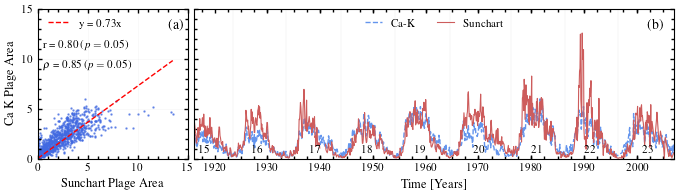

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import matplotlib as mpl
from datetime import datetime

# Set style
mpl.style.use('bkj_style.mplstyle')
plt.rcParams['font.size'] = 9

# Create figure with two subplots
fig = plt.figure(figsize=(6, 6))

# --- LEFT PLOT: Correlation ---
ax1 = fig.add_axes([0.01, 0.1, 0.25, 0.25])  # [left, bottom, width, height]

# Load and process data for correlation plot
df_sunchart = pd.read_csv('data/filtered_sunchart_non_zero.txt', sep='\s+', header=None)
dates_sunchart = pd.to_datetime(df_sunchart[0])
total_plage_area_sunchart = np.sum(df_sunchart.drop(columns=0).values, axis=1)
data_sunchart = pd.DataFrame({'Date': dates_sunchart, 'SunChart_Plage': total_plage_area_sunchart})



df_kso = pd.read_csv("data/kso_plage1.txt", delim_whitespace=True, header=None,
                     names=['year', 'month', 'day', 'hour', 'minute', 'date_fract',
                           'julian_date', 'disc_area_px', 'plage_proj', 'plage_corr'])

# Process KSO data
numeric_cols = ['year', 'month', 'day', 'hour', 'minute', 'plage_corr']
for col in numeric_cols:
    df_kso[col] = pd.to_numeric(df_kso[col], errors='coerce')
df_kso = df_kso.dropna(subset=numeric_cols)
df_kso['datetime'] = pd.to_datetime({
    'year': df_kso['year'], 'month': df_kso['month'], 'day': df_kso['day'],
    'hour': df_kso['hour'], 'minute': df_kso['minute']
})

# Merge datasets
data_sunchart['Date'] = pd.to_datetime(data_sunchart['Date'].dt.date)
df_kso['Date'] = pd.to_datetime(df_kso['datetime'].dt.date)
merged_data = pd.merge(data_sunchart, df_kso, on='Date', how='inner')

# Calculate monthly means
merged_data['YearMonth'] = merged_data['Date'].dt.to_period('M')
monthly_means = merged_data.groupby('YearMonth').agg({
    'SunChart_Plage': 'mean',
    'plage_corr': 'mean'
}).reset_index()
monthly_means['YearMonth'] = monthly_means['YearMonth'].dt.to_timestamp()

# Correlation plot
x = monthly_means['SunChart_Plage']*1e-4
y = monthly_means['plage_corr']*1e-4

# Calculate correlation coefficients
pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)

# Calculate regression line
slope = np.sum(x * y) / np.sum(x ** 2)  # Least-squares slope for y = bx
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit

# Plot correlation
ax1.scatter(x, y, color='royalblue', alpha=0.7, s=0.5, rasterized=True)
ax1.plot(x_fit, y_fit, color='red', linestyle='--', label=f'y = {slope:.2f}x')
#ax1.set_xlabel(r'Sunchart Plage Area ($\times 10^{4}$ $\mu$Hem)', fontsize=10)
#ax1.set_ylabel(r'Ca K Plage Area ($\times 10^{4}$ $\mu$Hem)', fontsize=10)
ax1.set_xlabel('Sunchart Plage Area', fontsize=9)
ax1.set_ylabel('Ca K Plage Area', fontsize=9)
ax1.annotate('r = 0.80 ($p=0.05$)', (0.5, 11), fontsize=8)
ax1.annotate(r'$\rho$ = 0.85 ($p=0.05$)', (0.5, 9), fontsize=8)
ax1.set_xlim(0, 15)
ax1.set_ylim(0, 15)
ax1.set_yticks([0,5,10,15])
ax1.tick_params(axis='both', labelsize=8)
ax1.text(13, 13, '(a)', fontsize=10)
ax1.legend(fontsize=8, loc=2, frameon=False)

# --- RIGHT PLOT: Time Series ---
ax2 = fig.add_axes([0.27, 0.1, 0.8, 0.25])  # Positioned to the right

# Prepare monthly data for time series

# Set 1940 values to NaN for Sunchart
data_sunchart.loc[data_sunchart['Date'].dt.year == 1940, 'SunChart_Plage'] = np.nan


data_sunchart['YearMonth'] = data_sunchart['Date'].dt.to_period('M')
monthly_sunchart = data_sunchart.groupby('YearMonth')['SunChart_Plage'].mean().reset_index()
monthly_sunchart['YearMonth'] = monthly_sunchart['YearMonth'].dt.to_timestamp()

df_kso['YearMonth'] = df_kso['datetime'].dt.to_period('M')
monthly_kso = df_kso.groupby('YearMonth')['plage_corr'].mean().reset_index()
monthly_kso['YearMonth'] = monthly_kso['YearMonth'].dt.to_timestamp()

# Time series plot
# ax2.scatter(monthly_kso['YearMonth'], monthly_kso['plage_corr']*1e-4, 
#         color='cornflowerblue', linewidth=0,s=1.5,alpha=0.9, label='Ca-K',rasterized=True)
# ax2.scatter(monthly_sunchart['YearMonth'], monthly_sunchart['SunChart_Plage']*1e-4, 
#         color='indianred', linewidth=0,s=1.5,alpha=0.9, label='Sunchart',rasterized=True)

ax2.plot(monthly_kso['YearMonth'], monthly_kso['plage_corr']*1e-4, 
        color='cornflowerblue', linewidth=1.0, label='Ca-K',linestyle='--',rasterized=True)
ax2.plot(monthly_sunchart['YearMonth'], monthly_sunchart['SunChart_Plage']*1e-4, 
        color='indianred', linewidth=0.8, label='Sunchart',rasterized=True)

# Formatting
ax2.set_xlim(datetime(1916, 1, 1), datetime(2007, 1, 1))
ax2.set_ylim(0, 150000*1e-4)
ax2.set_yticks([0,5,10,15])
ax2.set_xlabel('Time [Years]')
#ax2.set_ylabel(r'Plage Area [$\mu$Hem]')
#ax2.legend(loc='upper right', fontsize=8)
ax2.tick_params(axis='both', labelsize=8,labelleft=False)
legend = ax2.legend(ncols=2, loc='upper center', handlelength=1.5, fontsize=8,
                   markerscale=3)  # markerscale makes legend markers larger

ax2.text(datetime(2002,1,1), 13, '(b)', fontsize=10)
ax2.grid()


# Add solar cycle markings
cycle_dates = [
    (datetime(1923,6,1), '15'),
    (datetime(1933,7,1), '16'),
    (datetime(1944,1,1), '17'),
    (datetime(1954,3,1), '18'),
    (datetime(1964,8,1), '19'),
    (datetime(1976,2,1), '20'),
    (datetime(1986,7,1), '21'),
    (datetime(1996,6,1), '22'),
    (datetime(2007,5,1), '23')
]

for date, cycle_num in cycle_dates:
    ax2.axvline(date, color='black', linestyle='-', linewidth=0.3, alpha=0.1)
    


ax2.text(datetime(1917,1,1), 0.6, '15',size=8)
ax2.text(datetime(1927,1,1), 0.6, '16',size=8)
ax2.text(datetime(1938,1,1), 0.6, '17',size=8)
ax2.text(datetime(1948,1,1), 0.6, '18',size=8)
ax2.text(datetime(1958,1,1), 0.6, '19',size=8)
ax2.text(datetime(1969,1,1), 0.6, '20',size=8)
ax2.text(datetime(1980,1,1), 0.6, '21',size=8)
ax2.text(datetime(1990,1,1), 0.6,'22',size=8)
ax2.text(datetime(2001,1,1), 0.6, '23',size=8)


# Adjust layout and save
plt.savefig('combined_plage.pdf', bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_76844/2274580857.py:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_kso = pd.read_csv("kso_plage1.txt", delim_whitespace=True, header=None,


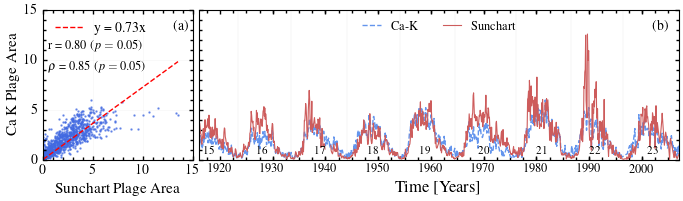

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import matplotlib as mpl
from datetime import datetime

# Set style
mpl.style.use('bkj_style.mplstyle')
plt.rcParams['font.size'] = 12

# Create figure with two subplots
fig = plt.figure(figsize=(6, 6))

# --- LEFT PLOT: Correlation ---
ax1 = fig.add_axes([0.01, 0.1, 0.25, 0.25])  # [left, bottom, width, height]

# Load and process data for correlation plot
df_sunchart = pd.read_csv('data/filtered_sunchart_non_zero.txt', sep='\s+', header=None)
dates_sunchart = pd.to_datetime(df_sunchart[0])
total_plage_area_sunchart = np.sum(df_sunchart.drop(columns=0).values, axis=1)
data_sunchart = pd.DataFrame({'Date': dates_sunchart, 'SunChart_Plage': total_plage_area_sunchart})



df_kso = pd.read_csv("data/kso_plage1.txt", delim_whitespace=True, header=None,
                     names=['year', 'month', 'day', 'hour', 'minute', 'date_fract',
                           'julian_date', 'disc_area_px', 'plage_proj', 'plage_corr'])

# Process KSO data
numeric_cols = ['year', 'month', 'day', 'hour', 'minute', 'plage_corr']
for col in numeric_cols:
    df_kso[col] = pd.to_numeric(df_kso[col], errors='coerce')
df_kso = df_kso.dropna(subset=numeric_cols)
df_kso['datetime'] = pd.to_datetime({
    'year': df_kso['year'], 'month': df_kso['month'], 'day': df_kso['day'],
    'hour': df_kso['hour'], 'minute': df_kso['minute']
})

# Merge datasets
data_sunchart['Date'] = pd.to_datetime(data_sunchart['Date'].dt.date)
df_kso['Date'] = pd.to_datetime(df_kso['datetime'].dt.date)
merged_data = pd.merge(data_sunchart, df_kso, on='Date', how='inner')

# Calculate monthly means
merged_data['YearMonth'] = merged_data['Date'].dt.to_period('M')
monthly_means = merged_data.groupby('YearMonth').agg({
    'SunChart_Plage': 'mean',
    'plage_corr': 'mean'
}).reset_index()
monthly_means['YearMonth'] = monthly_means['YearMonth'].dt.to_timestamp()

# Correlation plot
x = monthly_means['SunChart_Plage']*1e-4
y = monthly_means['plage_corr']*1e-4

# Calculate correlation coefficients
pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)

# Calculate regression line
slope = np.sum(x * y) / np.sum(x ** 2)  # Least-squares slope for y = bx
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit

# Plot correlation
ax1.scatter(x, y, color='royalblue', alpha=0.7, s=0.5, rasterized=True)
ax1.plot(x_fit, y_fit, color='red', linestyle='--', label=f'y = {slope:.2f}x')
#ax1.set_xlabel(r'Sunchart Plage Area ($\times 10^{4}$ $\mu$Hem)', fontsize=10)
#ax1.set_ylabel(r'Ca K Plage Area ($\times 10^{4}$ $\mu$Hem)', fontsize=10)
ax1.set_xlabel('Sunchart Plage Area', fontsize=11)
ax1.set_ylabel('Ca K Plage Area', fontsize=11)
ax1.annotate('r = 0.80 ($p=0.05$)', (0.5, 11), fontsize=9)
ax1.annotate(r'$\rho$ = 0.85 ($p=0.05$)', (0.5, 9), fontsize=9)
ax1.set_xlim(0, 15)
ax1.set_ylim(0, 15)
ax1.set_yticks([0,5,10,15])
ax1.tick_params(axis='both', labelsize=10)
ax1.text(13, 13, '(a)', fontsize=10)
ax1.legend(fontsize=10, loc=2, frameon=False)

# --- RIGHT PLOT: Time Series ---
ax2 = fig.add_axes([0.27, 0.1, 0.8, 0.25])  # Positioned to the right

# Prepare monthly data for time series

# Set 1940 values to NaN for Sunchart
data_sunchart.loc[data_sunchart['Date'].dt.year == 1940, 'SunChart_Plage'] = np.nan


data_sunchart['YearMonth'] = data_sunchart['Date'].dt.to_period('M')
monthly_sunchart = data_sunchart.groupby('YearMonth')['SunChart_Plage'].mean().reset_index()
monthly_sunchart['YearMonth'] = monthly_sunchart['YearMonth'].dt.to_timestamp()

df_kso['YearMonth'] = df_kso['datetime'].dt.to_period('M')
monthly_kso = df_kso.groupby('YearMonth')['plage_corr'].mean().reset_index()
monthly_kso['YearMonth'] = monthly_kso['YearMonth'].dt.to_timestamp()

# Time series plot
# ax2.scatter(monthly_kso['YearMonth'], monthly_kso['plage_corr']*1e-4, 
#         color='cornflowerblue', linewidth=0,s=1.5,alpha=0.9, label='Ca-K',rasterized=True)
# ax2.scatter(monthly_sunchart['YearMonth'], monthly_sunchart['SunChart_Plage']*1e-4, 
#         color='indianred', linewidth=0,s=1.5,alpha=0.9, label='Sunchart',rasterized=True)

ax2.plot(monthly_kso['YearMonth'], monthly_kso['plage_corr']*1e-4, 
        color='cornflowerblue', linewidth=1.0, label='Ca-K',linestyle='--',rasterized=True)
ax2.plot(monthly_sunchart['YearMonth'], monthly_sunchart['SunChart_Plage']*1e-4, 
        color='indianred', linewidth=0.8, label='Sunchart',rasterized=True)

# Formatting
ax2.set_xlim(datetime(1916, 1, 1), datetime(2007, 1, 1))
ax2.set_ylim(0, 150000*1e-4)
ax2.set_yticks([0,5,10,15])
ax2.set_xlabel('Time [Years]')
#ax2.set_ylabel(r'Plage Area [$\mu$Hem]')
#ax2.legend(loc='upper right', fontsize=8)
ax2.tick_params(axis='both', labelsize=9,labelleft=False)
legend = ax2.legend(ncols=2, loc='upper center', handlelength=1.5, fontsize=9,
                   markerscale=3)  # markerscale makes legend markers larger

ax2.text(datetime(2002,1,1), 13, '(b)', fontsize=10)
ax2.grid()


# Add solar cycle markings
cycle_dates = [
    (datetime(1923,6,1), '15'),
    (datetime(1933,7,1), '16'),
    (datetime(1944,1,1), '17'),
    (datetime(1954,3,1), '18'),
    (datetime(1964,8,1), '19'),
    (datetime(1976,2,1), '20'),
    (datetime(1986,7,1), '21'),
    (datetime(1996,6,1), '22'),
    (datetime(2007,5,1), '23')
]

for date, cycle_num in cycle_dates:
    ax2.axvline(date, color='black', linestyle='-', linewidth=0.3, alpha=0.1)
    


ax2.text(datetime(1917,1,1), 0.6, '15',size=8)
ax2.text(datetime(1927,1,1), 0.6, '16',size=8)
ax2.text(datetime(1938,1,1), 0.6, '17',size=8)
ax2.text(datetime(1948,1,1), 0.6, '18',size=8)
ax2.text(datetime(1958,1,1), 0.6, '19',size=8)
ax2.text(datetime(1969,1,1), 0.6, '20',size=8)
ax2.text(datetime(1980,1,1), 0.6, '21',size=8)
ax2.text(datetime(1990,1,1), 0.6,'22',size=8)
ax2.text(datetime(2001,1,1), 0.6, '23',size=8)


# Adjust layout and save
plt.savefig('combined_plage.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [46]:
import pandas as pd
import numpy as np

# Load and process KSO data
df_kso = pd.read_csv('data/kso_plage1.txt', delim_whitespace=True, header=None,
                    names=['year', 'month', 'day', 'hour', 'minute', 'date_fract',
                          'julian_date', 'disc_area_px', 'plage_proj', 'plage_corr'])
# Convert numeric columns - handle potential non-numeric values
numeric_cols = ['year', 'month', 'day', 'hour', 'minute', 'plage_corr']
for col in numeric_cols:
    df_kso[col] = pd.to_numeric(df_kso[col], errors='coerce')
    
# Drop rows with invalid numeric values
df_kso = df_kso.dropna(subset=numeric_cols)

# Convert to datetime and filter 1940 data
df_kso['datetime'] = pd.to_datetime({
    'year': df_kso['year'],
    'month': df_kso['month'],
    'day': df_kso['day'],
    'hour': df_kso['hour'],
    'minute': df_kso['minute']
})
kso_1940 = df_kso[df_kso['year'] == 1940][['datetime', 'plage_corr']]

# Load SunChart data
df_sunchart = pd.read_csv('data/filtered_sunchart_non_zero1.txt', sep='\s+', header=None)
dates_sunchart = pd.to_datetime(df_sunchart[0])
plage_areas_sunchart = df_sunchart.drop(columns=0).values
total_plage_area_sunchart = np.sum(plage_areas_sunchart, axis=1)

# Create combined DataFrame
combined = pd.DataFrame({
    'timestamp': dates_sunchart,
    'total_area': total_plage_area_sunchart
})

# Replace 1940 data with KSO values
mask_1940 = combined['timestamp'].dt.year == 1940
combined.loc[mask_1940, 'total_area'] = kso_1940['plage_corr'].values[:sum(mask_1940)]

# Save to file in required format
combined['timestamp_str'] = combined['timestamp'].dt.strftime('%Y-%m-%dT%H:%M:%S')
combined[['timestamp_str', 'total_area']].to_csv('combined_plage_data.txt', 
                                               sep='\t', 
                                               index=False, 
                                               header=False)

/tmp/ipykernel_14657/3707295638.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_kso = pd.read_csv('kso_plage1.txt', delim_whitespace=True, header=None,


In [14]:
import pandas as pd
import numpy as np

# Load and process KSO data
df_kso = pd.read_csv('data/kso_plage1.txt', delim_whitespace=True, header=None,
                    names=['year', 'month', 'day', 'hour', 'minute', 'date_fract',
                          'julian_date', 'disc_area_px', 'plage_proj', 'plage_corr'])

# Convert numeric columns
numeric_cols = ['year', 'month', 'day', 'hour', 'minute', 'plage_corr']
for col in numeric_cols:
    df_kso[col] = pd.to_numeric(df_kso[col], errors='coerce')
    
# Drop rows with invalid numeric values
df_kso = df_kso.dropna(subset=numeric_cols)

# Convert to datetime
df_kso['datetime'] = pd.to_datetime({
    'year': df_kso['year'],
    'month': df_kso['month'],
    'day': df_kso['day'],
    'hour': df_kso['hour'],
    'minute': df_kso['minute']
})

# Define target years including 1940 and additional years
target_years = [1940, 1996, 1997, 2003, 2004, 2005]
kso_target = df_kso[df_kso['year'].isin(target_years)][['datetime', 'plage_corr']]

# Load SunChart data
df_sunchart = pd.read_csv('data/filtered_sunchart_non_zero1.txt', sep='\s+', header=None)
dates_sunchart = pd.to_datetime(df_sunchart[0])
plage_areas_sunchart = df_sunchart.drop(columns=0).values
total_plage_area_sunchart = np.sum(plage_areas_sunchart, axis=1)

# Create combined DataFrame
combined = pd.DataFrame({
    'timestamp': dates_sunchart,
    'total_area': total_plage_area_sunchart
})

# Replace data for all target years with KSO values
for year in target_years:
    # Filter KSO data for the current year
    kso_year = kso_target[kso_target['datetime'].dt.year == year]
    
    if len(kso_year) > 0:
        # Create a mapping dictionary (date: plage_corr)
        date_value_map = dict(zip(
            kso_year['datetime'].dt.normalize(),  # Remove time component
            kso_year['plage_corr']
        ))
        
        # Create mask for current year in combined data
        year_mask = combined['timestamp'].dt.year == year
        
        # Replace values using the mapping
        combined.loc[year_mask, 'total_area'] = (
            combined.loc[year_mask, 'timestamp'].dt.normalize()
            .map(date_value_map)
            .ffill()  # Forward fill any missing dates
            .bfill()  # Backward fill any remaining missing dates
        )
    else:
        print(f"Warning: No KSO data found for year {year}")

# Handle any remaining missing values (if KSO data didn't cover all dates)
combined['total_area'] = combined['total_area'].ffill().bfill()

# Save to file in required format
combined['timestamp_str'] = combined['timestamp'].dt.strftime('%Y-%m-%dT%H:%M:%S')
combined[['timestamp_str', 'total_area']].to_csv('combined_plage_data.txt', 
                                               sep='\t', 
                                               index=False, 
                                               header=False)

print("Data processing complete. Combined data saved to 'combined_plage_data.txt'")

/tmp/ipykernel_36944/1075541407.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_kso = pd.read_csv('kso_plage1.txt', delim_whitespace=True, header=None,


Data processing complete. Combined data saved to 'combined_plage_data.txt'


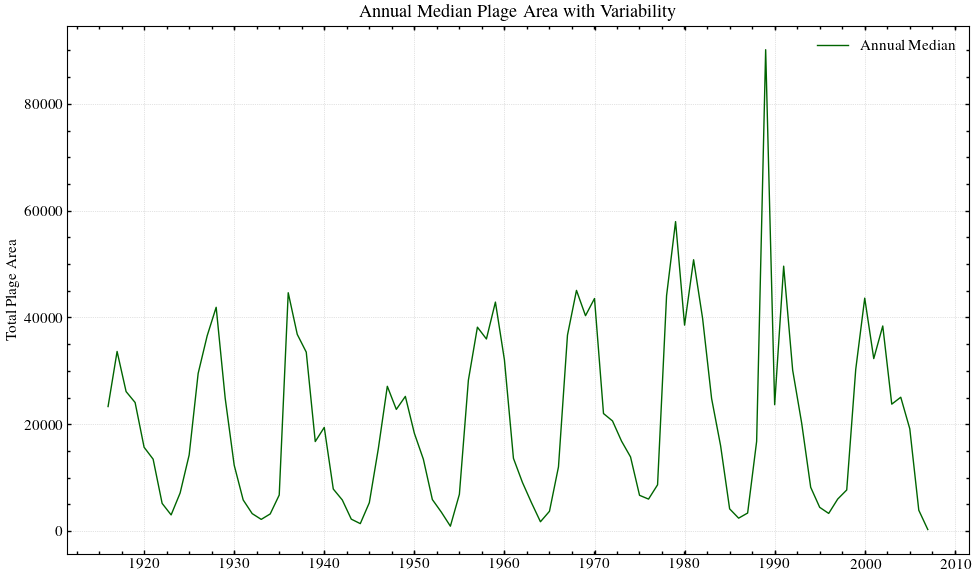

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Read the combined data
df_composite = pd.read_csv('data/combined_plage_data.txt', 
                 sep='\t', 
                 header=None,
                 names=['timestamp_str', 'total_area'])
df_composite['timestamp_str'] = pd.to_datetime(df_composite['timestamp_str'])

# 2. Calculate annual statistics
annual_stats_composite = df_composite.groupby(df_composite['timestamp_str'].dt.year).agg(
    median=('total_area', 'median')).reset_index()

# Convert year to datetime for plotting
annual_stats_composite['Date'] = pd.to_datetime(annual_stats_composite['timestamp_str'], format='%Y')

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Main median line
ax.plot(annual_stats_composite['Date'], annual_stats_composite['median'], 
        color='darkgreen', linewidth=1.0, label='Annual Median')


# Formatting
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylabel('Total Plage Area')
ax.set_title('Annual Median Plage Area with Variability')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

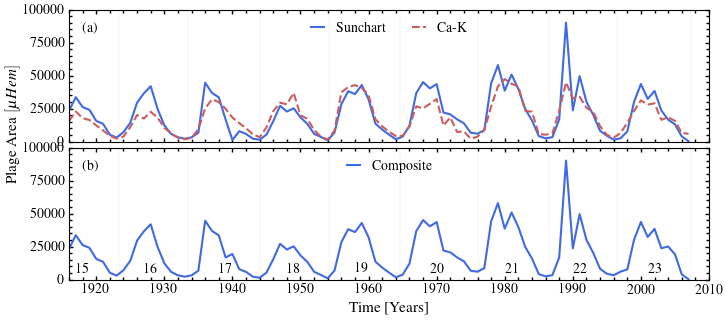

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

plt.rcParams['font.size'] = 11

fig = plt.figure(figsize=(8,6))
ax2 = fig.add_axes([0.01, 0.24, 0.8, 0.22])  # chatterjee (2016)
ax3 = fig.add_axes([0.01, 0.47, 0.8, 0.22])  # jha (2024)

# --- Common x-axis parameters ---
major_xticks = [datetime(year, 1, 1) for year in range(1920, 2011, 10)]
minor_xticks = [datetime(year, 1, 1) for year in range(1916, 2011, 2)]
major_xticks_fractional = range(1920, 2011, 10)
minor_xticks_fractional = range(1916, 2011, 2)

# --- Top plot (ax3) ---
# [Your existing data loading and processing code for ax3]

# ax3.scatter(data_sunchart['Date'], data_sunchart['Total_Plage'], 
#            color='lightcoral', s=0.3, alpha=0.7, linewidth=0.5, label='Daily Plage Area')
ax3.plot(annual_stats['Date'], annual_stats['median'], 
        color='royalblue', linewidth=1.5, label='Sunchart')
ax3.plot(annual_stats['Date'], annual_median['plage_corr'],
        color='indianred', linewidth=1.5, label='Ca-K',linestyle='--')
# ax3.fill_between(annual_stats['Date'], 
#                 annual_stats['median'] - annual_stats['semedian'],
#                 annual_stats['median'] + annual_stats['semedian'],
#                 color='darkgreen', alpha=0.5)

ax3.set_ylim(0, 100000)
ax3.set_xlim(datetime(1916, 1, 1), datetime(2007, 1, 1))
#ax3.set_yticks([0, 50000, 100000, 150000, 200000])
ax3.set_xticks(major_xticks)
ax3.set_xticks(minor_xticks, minor=True)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.tick_params(axis='both', labelsize=10, labelbottom=False)
ax3.grid()
ax3.legend(ncols=2, loc='upper center', handlelength=1.0, fontsize=10)
ax3.text(0.02, 0.83, '(a)', transform=ax3.transAxes, fontsize=10)

# --- Bottom plot (ax2) ---
# [Your existing data loading and processing code for ax2]

ax2.plot(annual_stats_composite['Date'], annual_stats_composite['median'], 
        color='royalblue', linewidth=1.5, label='Composite')

ax2.set_ylim(0, 100000)
ax2.set_xlim(datetime(1916, 1, 1), datetime(2007, 1, 1))
#ax2.set_yticks([0, 50000, 100000, 150000, 200000])
ax2.set_xticks(major_xticks)
ax2.set_xticks(minor_xticks, minor=True)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.tick_params(axis='both', labelsize=10)
ax2.grid()
ax2.legend(ncols=2, loc='upper center', handlelength=1.0, fontsize=10)
ax2.text(0.02, 0.83, '(b)', transform=ax2.transAxes, fontsize=10)
ax2.set_xlabel('Time [Years]')

ax3.axvline(datetime(1923,6,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1933,7,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1944,1,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1954,3,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1964,8,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1976,2,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1986,7,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1996,6,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(2007,5,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)


ax2.axvline(datetime(1923,6,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(datetime(1933,7,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(datetime(1944,1,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(datetime(1954,3,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(datetime(1964,8,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(datetime(1976,2,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(datetime(1986,7,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(datetime(1996,6,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax2.axvline(datetime(2007,5,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)

ax2.text(datetime(1917,1,1), 5000, '15',size=10)
ax2.text(datetime(1927,1,1), 5000, '16',size=10)
ax2.text(datetime(1938,1,1), 5000, '17',size=10)
ax2.text(datetime(1948,1,1), 5000, '18',size=10)
ax2.text(datetime(1958,1,1), 5000, '19',size=10)
ax2.text(datetime(1969,1,1), 5000, '20',size=10)
ax2.text(datetime(1980,1,1), 5000, '21',size=10)
ax2.text(datetime(1990,1,1), 5000,'22',size=10)
ax2.text(datetime(2001,1,1), 5000, '23',size=10)


fig.text(-0.07, 0.5, r'Plage Area $[\mu Hem]$', va='center', rotation='vertical')
plt.savefig('plage_area.pdf', bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_113188/3703826157.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(ncols=2, loc='upper center', handlelength=1.0, fontsize=10)


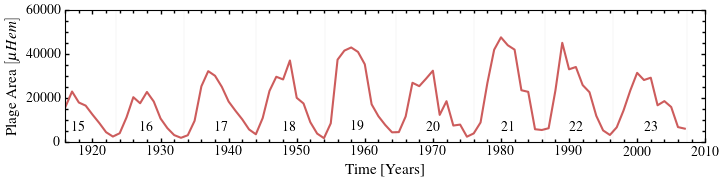

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

plt.rcParams['font.size'] = 11

fig = plt.figure(figsize=(8,6))
#ax2 = fig.add_axes([0.01, 0.24, 0.8, 0.22])  # chatterjee (2016)
ax3 = fig.add_axes([0.01, 0.47, 0.8, 0.22])  # jha (2024)

# --- Common x-axis parameters ---
major_xticks = [datetime(year, 1, 1) for year in range(1920, 2011, 10)]
minor_xticks = [datetime(year, 1, 1) for year in range(1916, 2011, 2)]
major_xticks_fractional = range(1920, 2011, 10)
minor_xticks_fractional = range(1916, 2011, 2)

# --- Top plot (ax3) ---
# [Your existing data loading and processing code for ax3]

# ax3.scatter(data_sunchart['Date'], data_sunchart['Total_Plage'], 
#            color='lightcoral', s=0.3, alpha=0.7, linewidth=0.5, label='Daily Plage Area')
# ax3.plot(annual_stats['Date'], annual_stats['median'], 
#         color='royalblue', linewidth=1.5, label='Sunchart')
ax3.plot(annual_stats['Date'], annual_median['plage_corr'],
        color='indianred', linewidth=1.5,linestyle='-')
# ax3.fill_between(annual_stats['Date'], 
#                 annual_stats['median'] - annual_stats['semedian'],
#                 annual_stats['median'] + annual_stats['semedian'],
#                 color='darkgreen', alpha=0.5)

ax3.set_ylim(0, 60000)
ax3.set_xlim(datetime(1916, 1, 1), datetime(2007, 1, 1))
#ax3.set_yticks([0, 50000, 100000, 150000, 200000])
ax3.set_xticks(major_xticks)
ax3.set_xticks(minor_xticks, minor=True)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.tick_params(axis='both', labelsize=10)
ax3.grid()
ax3.legend(ncols=2, loc='upper center', handlelength=1.0, fontsize=10)
#ax3.text(0.02, 0.83, '(a)', transform=ax3.transAxes, fontsize=10)

ax3.set_xlabel('Time [Years]')
ax3.set_ylabel(r'Plage Area $[\mu Hem]$')

# --- Bottom plot (ax2) ---
# [Your existing data loading and processing code for ax2]

# ax2.plot(annual_stats_composite['Date'], annual_stats_composite['median'], 
#         color='royalblue', linewidth=1.5, label='Composite')

# ax2.set_ylim(0, 100000)
# ax2.set_xlim(datetime(1916, 1, 1), datetime(2007, 1, 1))
# #ax2.set_yticks([0, 50000, 100000, 150000, 200000])
# ax2.set_xticks(major_xticks)
# ax2.set_xticks(minor_xticks, minor=True)
# ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# ax2.tick_params(axis='both', labelsize=10)
# ax2.grid()
# ax2.legend(ncols=2, loc='upper center', handlelength=1.0, fontsize=10)
# ax2.text(0.02, 0.83, '(b)', transform=ax2.transAxes, fontsize=10)
# ax2.set_xlabel('Time [Years]')

ax3.axvline(datetime(1923,6,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1933,7,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1944,1,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1954,3,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1964,8,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1976,2,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1986,7,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(1996,6,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
ax3.axvline(datetime(2007,5,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)


# ax2.axvline(datetime(1923,6,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
# ax2.axvline(datetime(1933,7,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
# ax2.axvline(datetime(1944,1,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
# ax2.axvline(datetime(1954,3,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
# ax2.axvline(datetime(1964,8,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
# ax2.axvline(datetime(1976,2,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
# ax2.axvline(datetime(1986,7,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
# ax2.axvline(datetime(1996,6,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)
# ax2.axvline(datetime(2007,5,1), color='black',linestyle='-',linewidth=0.3,alpha=0.1)

ax3.text(datetime(1917,1,1), 5000, '15',size=10)
ax3.text(datetime(1927,1,1), 5000, '16',size=10)
ax3.text(datetime(1938,1,1), 5000, '17',size=10)
ax3.text(datetime(1948,1,1), 5000, '18',size=10)
ax3.text(datetime(1958,1,1), 5000, '19',size=10)
ax3.text(datetime(1969,1,1), 5000, '20',size=10)
ax3.text(datetime(1980,1,1), 5000, '21',size=10)
ax3.text(datetime(1990,1,1), 5000,'22',size=10)
ax3.text(datetime(2001,1,1), 5000, '23',size=10)


#fig.text(-0.07, 0.5, r'Plage Area $[\mu Hem]$', va='center', rotation='vertical')
plt.savefig('plage_area_cak.pdf', bbox_inches='tight', dpi=300)
plt.show()

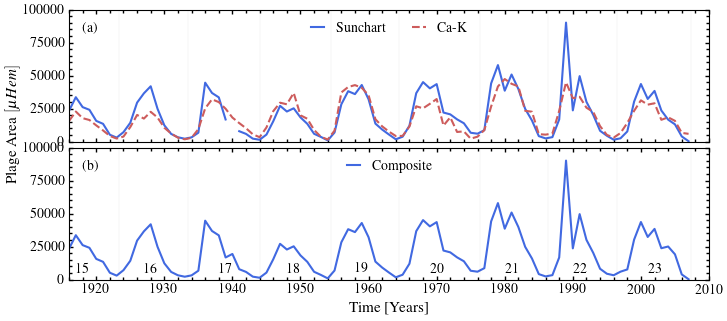

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.dates as mdates

mpl.style.use('bkj_style.mplstyle')
plt.rcParams['font.size'] = 11

fig = plt.figure(figsize=(8,6))
ax2 = fig.add_axes([0.01, 0.24, 0.8, 0.22])  # chatterjee (2016)
ax3 = fig.add_axes([0.01, 0.47, 0.8, 0.22])  # jha (2024)

# --- Common x-axis parameters ---
major_xticks = [datetime(year, 1, 1) for year in range(1920, 2011, 10)]
minor_xticks = [datetime(year, 1, 1) for year in range(1916, 2011, 2)]
major_xticks_fractional = range(1920, 2011, 10)
minor_xticks_fractional = range(1916, 2011, 2)

# --- Top plot (ax3) ---
# Assuming annual_stats and annual_median are your DataFrames
# Add NaN for 1940 in both datasets
annual_stats.loc[annual_stats['Date'].dt.year == 1940, 'median'] = np.nan
#annual_median.loc[annual_median['Date'].dt.year == 1940, 'plage_corr'] = np.nan

ax3.plot(annual_stats['Date'], annual_stats['median'], 
        color='royalblue', linewidth=1.5, label='Sunchart')
ax3.plot(annual_stats['Date'], annual_median['plage_corr'],
        color='indianred', linewidth=1.5, label='Ca-K', linestyle='--')

ax3.set_ylim(0, 100000)
ax3.set_xlim(datetime(1916, 1, 1), datetime(2007, 1, 1))
ax3.set_xticks(major_xticks)
ax3.set_xticks(minor_xticks, minor=True)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.tick_params(axis='both', labelsize=10, labelbottom=False)
ax3.grid()
ax3.legend(ncols=2, loc='upper center', handlelength=1.0, fontsize=10)
ax3.text(0.02, 0.83, '(a)', transform=ax3.transAxes, fontsize=10)

# --- Bottom plot (ax2) ---
# Add NaN for 1940 in composite data
#annual_stats_composite.loc[annual_stats_composite['Date'].dt.year == 1940, 'median'] = np.nan

ax2.plot(annual_stats_composite['Date'], annual_stats_composite['median'], 
        color='royalblue', linewidth=1.5, label='Composite')

ax2.set_ylim(0, 100000)
ax2.set_xlim(datetime(1916, 1, 1), datetime(2007, 1, 1))
ax2.set_xticks(major_xticks)
ax2.set_xticks(minor_xticks, minor=True)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.tick_params(axis='both', labelsize=10)
ax2.grid()
ax2.legend(ncols=2, loc='upper center', handlelength=1.0, fontsize=10)
ax2.text(0.02, 0.83, '(b)', transform=ax2.transAxes, fontsize=10)
ax2.set_xlabel('Time [Years]')

# Add vertical lines (unchanged)
for ax in [ax3, ax2]:
    for year in [1923, 1933, 1944, 1954, 1964, 1976, 1986, 1996, 2007]:
        ax.axvline(datetime(year, 6 if year != 1944 else 1, 1), 
                  color='black', linestyle='-', linewidth=0.3, alpha=0.1)

# Add cycle numbers (unchanged)
cycle_years = [(1917, '15'), (1927, '16'), (1938, '17'), (1948, '18'),
              (1958, '19'), (1969, '20'), (1980, '21'), (1990, '22'), (2001, '23')]

for year, num in cycle_years:
    ax2.text(datetime(year, 1, 1), 5000, num, size=10)

fig.text(-0.07, 0.5, r'Plage Area $[\mu Hem]$', va='center', rotation='vertical')
plt.savefig('plage_area.pdf', bbox_inches='tight', dpi=300)
plt.show()